In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
df_base_churn = pd.read_csv('../data/pre-processed/data_telcom_customer_churn_ibm.csv')

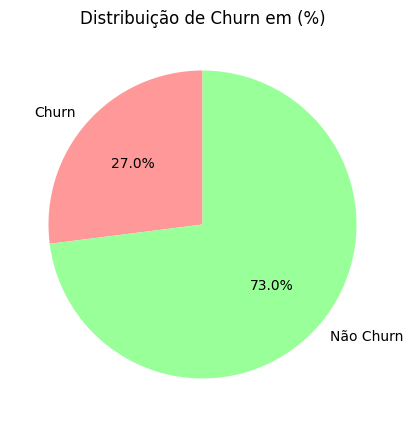

In [18]:
qtty_customers = df_base_churn['customer_id'].count()

qtty_churn = (df_base_churn['churn_value'] == 1).sum()
pct_churn = round(qtty_churn / qtty_customers, 2)

qtty_not_churn = (df_base_churn['churn_value'] == 0).sum()
pct_not_churn = round(qtty_not_churn / qtty_customers, 2)

df_proporcao_churn = pd.DataFrame({
    'qtty_customers': [qtty_customers],
    'qtty_churn': [qtty_churn],
    'pct_churn': [pct_churn],
    'qtty_not_churn': [qtty_not_churn],
    'pct_not_churn': [pct_not_churn]
})

df_grafico_proporcao_churn = df_proporcao_churn.copy()

labels = ['Churn', 'Não Churn']

sizes = [ 
         df_grafico_proporcao_churn['pct_churn'][0], 
         df_grafico_proporcao_churn['pct_not_churn'][0]
]

plt.figure(figsize=(5,5))
plt.pie(
    sizes,
    labels = labels,
    colors = ['#ff9999', '#99ff99'],
    autopct='%1.1f%%',
    startangle = 90
)

plt.title('Distribuição de Churn em (%)')
plt.show()

Text(0.5, 0, 'Quantidade de Clientes')

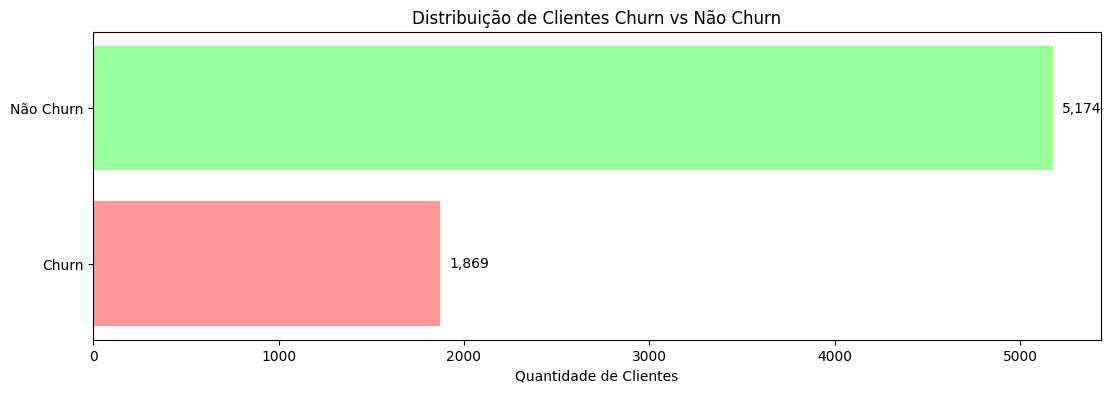

In [19]:
categories = ['Churn', 'Não Churn']
values = [
    df_grafico_proporcao_churn['qtty_churn'][0],
    df_grafico_proporcao_churn['qtty_not_churn'][0]
]

plt.figure(figsize=(13,4))

bars = plt.barh(
    categories,
    values,
    color=['#ff9999', '#99ff99']
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,
        bar.get_y() + bar.get_height()/2,
        f'{width:,}',
        va='center'
    )

plt.title('Distribuição de Clientes Churn vs Não Churn')
plt.xlabel('Quantidade de Clientes')


In [20]:
df_aux = df_base_churn.copy()

df_aux['churn_status'] = np.where(
    df_aux['churn_value'] == 1,
    'CHURN',
    'NOT_CHURN'
)

tbl_base = (
    df_aux
    .groupby(['tenure_months', 'churn_status'], as_index=False)
    .agg(qtty_customer=('customer_id', 'count'))
)

tbl_base = tbl_base.sort_values(
    ['tenure_months', 'qtty_customer'],
    ascending=[True, False]
)

df_resultado = (
    tbl_base
    .drop_duplicates(subset=['tenure_months'], keep='first')
    .reset_index(drop=True)
)

df_resultado

,tenure_months,churn_status,qtty_customer
0,0,NOT_CHURN,11
1,1,CHURN,380
2,2,CHURN,123
3,3,NOT_CHURN,106
4,4,NOT_CHURN,93
...,...,...,...
68,68,NOT_CHURN,91
69,69,NOT_CHURN,87
70,70,NOT_CHURN,108
71,71,NOT_CHURN,164


Insight: Os únicos meses em que a quantidade de clientes Churn supera a de Não Churn são os meses 1 e 2. Além disso, a concentração desses dois primeiros meses representa 26% de todo o volume de Churn da base. Esse comportamento indica que clientes com menor tempo de permanência possuem uma probabilidade significativamente maior de cancelamento, sugerindo que os primeiros meses da jornada do cliente são um período crítico para retenção.

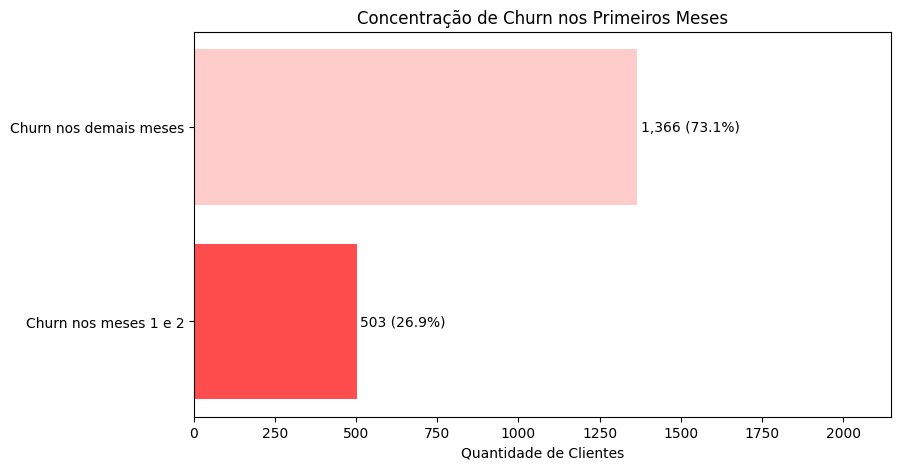

In [21]:
df_churn = df_base_churn[df_base_churn['churn_value'] == 1]

qtty_customers_churn = df_churn['customer_id'].count()

qtty_customers_churn_month_1_and_2 = (
    df_churn[df_churn['tenure_months'].isin([1, 2])]
    ['customer_id']
    .count()
)

df_proporcao_churn_month_1_and_2 = pd.DataFrame({
    'qtty_customers_churn': [qtty_customers_churn],
    'qtty_customers_churn_month_1_and_2': [qtty_customers_churn_month_1_and_2]
})

df_grafico_proporcao_churn_month_1_and_2 = (
    df_proporcao_churn_month_1_and_2.copy()
)

total_churn = df_grafico_proporcao_churn_month_1_and_2['qtty_customers_churn'][0]
month_1_2_churn = df_grafico_proporcao_churn_month_1_and_2['qtty_customers_churn_month_1_and_2'][0]
other_months = total_churn - month_1_2_churn

categories = [
    'Churn nos meses 1 e 2',
    'Churn nos demais meses'
]

values = [
    month_1_2_churn,
    other_months
]

plt.figure(figsize=(9,5))

bars = plt.barh(
    categories,
    values,
    color=['#ff4d4d','#ffcccc']
)

for i, bar in enumerate(bars):
    
    width = bar.get_width()
    pct = (width / total_churn) * 100
    
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,} ({pct:.1f}%)',
        va='center'
    )

plt.title('Concentração de Churn nos Primeiros Meses')
plt.xlabel('Quantidade de Clientes')

plt.xlim(0, total_churn * 1.15)

plt.show()

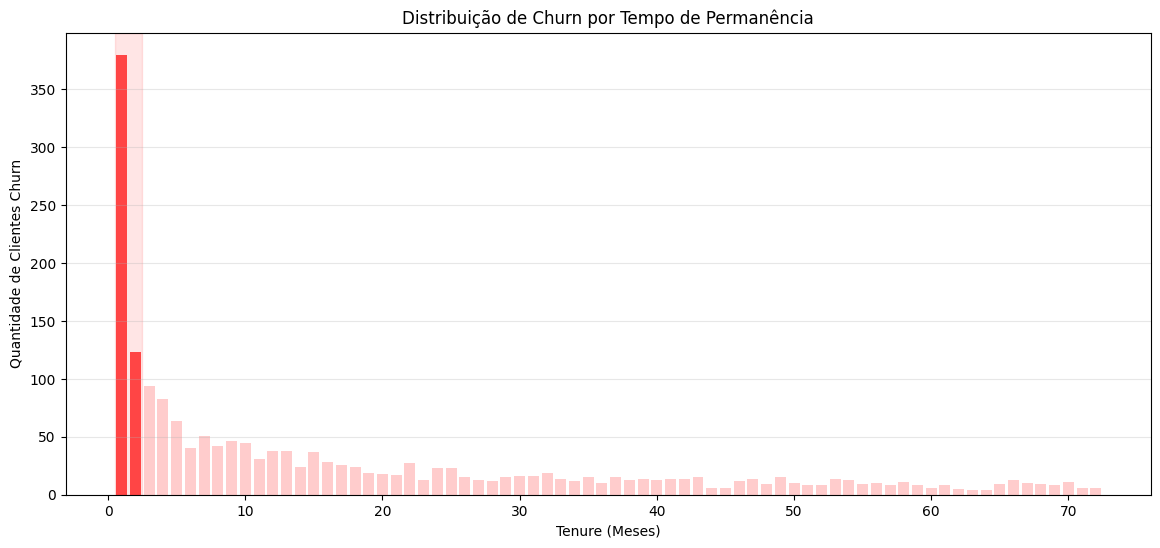

In [22]:
df_aux = df_base_churn.copy()

df_aux['churn_flag'] = np.where(
    df_aux['churn_value'] == 1,
    'CHURN',
    'NOT_CHURN'
)

df_churn_por_mes = (
    df_aux[df_aux['churn_flag'] == 'CHURN']
    .groupby('tenure_months', as_index=False)
    .agg(qtty_customer=('customer_id', 'count'))
    .sort_values('tenure_months')
)

df_grafico_churn_por_mes = df_churn_por_mes.copy()

colors = [
    '#ff4d4d' if month in [1, 2] else '#ffcccc'
    for month in df_grafico_churn_por_mes['tenure_months']
]

plt.figure(figsize=(14,6))

plt.bar(
    df_grafico_churn_por_mes['tenure_months'],
    df_grafico_churn_por_mes['qtty_customer'],
    color=colors
)

plt.title('Distribuição de Churn por Tempo de Permanência')
plt.xlabel('Tenure (Meses)')
plt.ylabel('Quantidade de Clientes Churn')

plt.grid(axis='y', alpha=0.3)

plt.axvspan(0.5, 2.5, alpha=0.1, color='red')

plt.show()

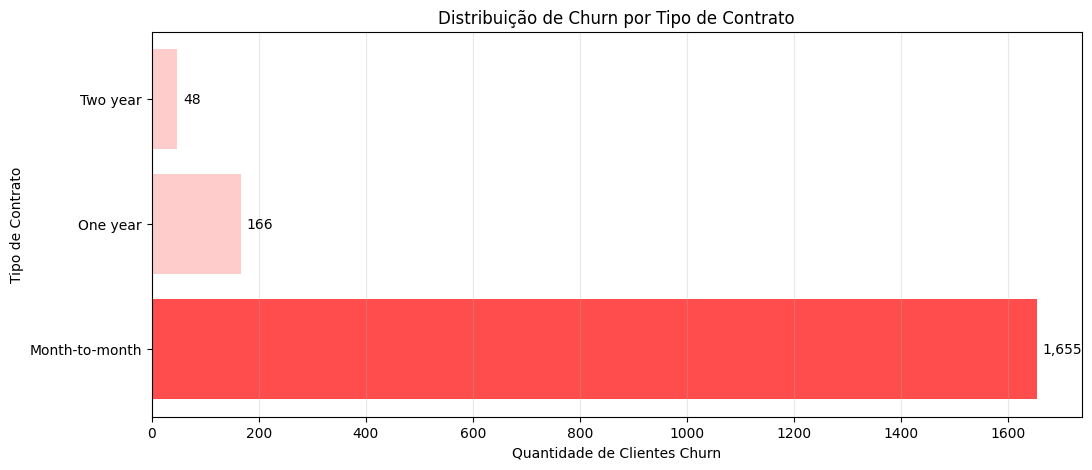

In [23]:
df_distribuicao_contract = (
    df_base_churn[df_base_churn['churn_value'] == 1]
    ['contract']
    .value_counts()
    .reset_index()
)

df_distribuicao_contract.columns = [
    'contract',
    'qtty_customer_churn'
]

df_grafico_distribuicao_contract = df_distribuicao_contract.copy()

colors = [
    '#ff4d4d' if contract == 'Month-to-month' else '#ffcccc'
    for contract in df_grafico_distribuicao_contract['contract']
]

plt.figure(figsize=(12,5))

bars = plt.barh(
    df_grafico_distribuicao_contract['contract'],
    df_grafico_distribuicao_contract['qtty_customer_churn'],
    color=colors
)

for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center'
    )

plt.title('Distribuição de Churn por Tipo de Contrato')
plt.xlabel('Quantidade de Clientes Churn')
plt.ylabel('Tipo de Contrato')

plt.grid(axis='x', alpha=0.3)

plt.show()

Insight: O tipo de contrato "Month-to-month" concentra a grande maioria dos clientes Churn da base, representando aproximadamente 89% de todo o volume de cancelamentos (1655 de 1869 clientes). Em contrapartida, contratos de longo prazo, como "One year" e principalmente "Two year", apresentam volumes significativamente menores de Churn. Esse comportamento indica uma forte relação entre duração contratual e retenção de clientes, sugerindo que contratos mensais possuem maior propensão ao cancelamento devido à menor barreira de saída e menor comprometimento de longo prazo. Já contratos anuais e bianuais demonstram um efeito relevante de retenção, funcionando como um possível fator protetivo contra Churn.

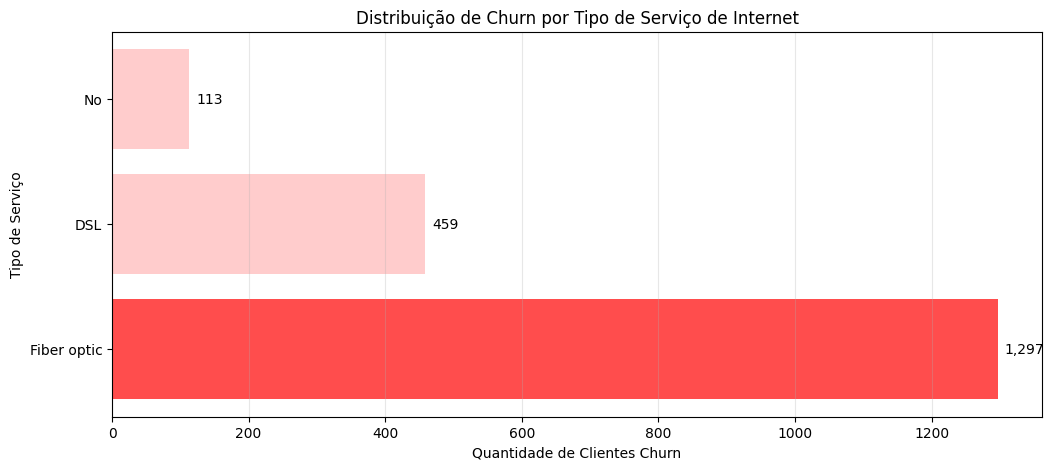

In [24]:
df_distribuicao_internet_service = (
    df_base_churn[df_base_churn['churn_value'] == 1]
    .groupby('internet_service', as_index=False)
    .agg(qtty_customers=('customer_id', 'count'))
    .sort_values('qtty_customers', ascending=False)
)

df_grafico_distribuicao_internet_service = (
    df_distribuicao_internet_service.copy()
)

colors = [
    '#ff4d4d' if service == 'Fiber optic' else '#ffcccc'
    for service in df_grafico_distribuicao_internet_service['internet_service']
]

plt.figure(figsize=(12,5))

bars = plt.barh(
    df_grafico_distribuicao_internet_service['internet_service'],
    df_grafico_distribuicao_internet_service['qtty_customers'],
    color=colors
)

for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center'
    )

plt.title('Distribuição de Churn por Tipo de Serviço de Internet')
plt.xlabel('Quantidade de Clientes Churn')
plt.ylabel('Tipo de Serviço')

plt.grid(axis='x', alpha=0.3)

plt.show()

Insight: O serviço de internet "Fiber optic" concentra a grande maioria dos clientes Churn da base, representando aproximadamente 69% de todo o volume de cancelamentos (1297 de 1869 clientes). Em contrapartida, clientes com serviço "DSL" apresentam um volume significativamente menor de Churn, enquanto clientes sem serviço de internet ("No") possuem participação pouco representativa.

Esse comportamento indica uma possível relação entre o tipo de serviço de internet e a propensão ao cancelamento, sugerindo que clientes Fiber optic podem estar mais expostos a fatores como preço elevado, expectativa de performance ou percepção de qualidade do serviço.

Já clientes com serviços mais estáveis ou com menor dependência do serviço de internet demonstram menor tendência ao Churn, funcionando como um possível fator de retenção.

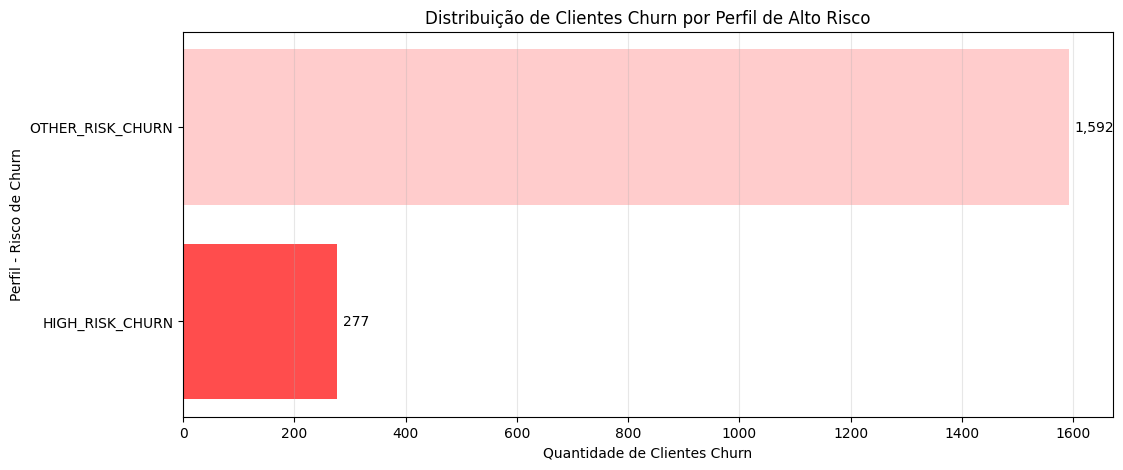

In [25]:
df_aux = df_base_churn.copy()

df_aux['high_risk_profile'] = np.where(
    (
        (df_aux['internet_service'] == 'Fiber optic') &
        (df_aux['contract'] == 'Month-to-month') &
        (df_aux['tenure_months'].isin([1, 2]))
    ),
    'HIGH_RISK_CHURN',
    'OTHER_RISK_CHURN'
)

df_high_risk_profile = (
    df_aux[df_aux['churn_value'] == 1]
    .groupby('high_risk_profile', as_index=False)
    .agg(qtty_customers=('customer_id', 'count'))
)

df_grafico_high_risk_profile = df_high_risk_profile.copy()

plt.figure(figsize=(12,5))

bars = plt.barh(
    df_grafico_high_risk_profile['high_risk_profile'],
    df_grafico_high_risk_profile['qtty_customers'],
    color=colors
)

for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center'
    )

plt.title('Distribuição de Clientes Churn por Perfil de Alto Risco')
plt.xlabel('Quantidade de Clientes Churn')
plt.ylabel('Perfil - Risco de Churn')

plt.grid(axis='x', alpha=0.3)

plt.show()

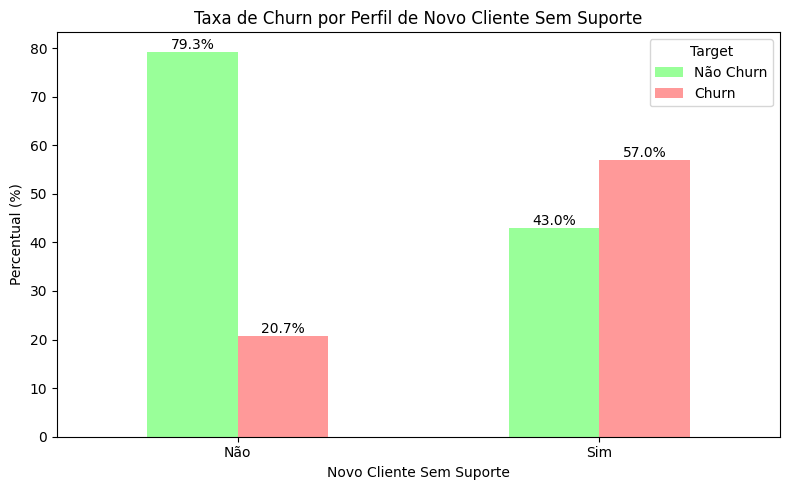

In [26]:
df = df_base_churn.copy()

df['partner'] = df['partner'].map({'No': 0, 'Yes': 1})
df['dependents'] = df['dependents'].map({'No': 0, 'Yes': 1})

df['is_new_customer'] = df['tenure_months'].isin([1, 2]).astype(int)

df['phone_services'] = df['phone_service'].map({'No': 0, 'Yes': 1})

df['multiples_lines'] = np.where(
    df['multiple_lines'].eq('Yes'),
    1,
    0
)

df['internet_dsl'] = (df['internet_service'] == 'DSL').astype(int)
df['internet_fiber'] = (df['internet_service'] == 'Fiber optic').astype(int)
df['internet_none'] = (df['internet_service'] == 'No').astype(int)

df['online_secutiry'] = df['online_security'].eq('Yes').astype(int)
df['online_backup'] = df['online_backup'].eq('Yes').astype(int)
df['device_protection'] = df['device_protection'].eq('Yes').astype(int)
df['tech_support'] = df['tech_support'].eq('Yes').astype(int)
df['streaming_tv'] = df['streaming_tv'].eq('Yes').astype(int)
df['streaming_movies'] = df['streaming_movies'].eq('Yes').astype(int)

df['contract_month_to_month'] = (
    df['contract'] == 'Month-to-month'
).astype(int)

df['contract_one_year'] = (
    df['contract'] == 'One year'
).astype(int)

df['contract_two_year'] = (
    df['contract'] == 'Two year'
).astype(int)


df['paperless_billing'] = (
    df['paperless_billing']
    .map({'No': 0, 'Yes': 1})
)

df['payment_method_mailed_check'] = (
    df['payment_method'] == 'Mailed check'
).astype(int)

df['payment_method_electronic_check'] = (
    df['payment_method'] == 'Electronic check'
).astype(int)

df['payment_method_bank_transfer_automatic'] = (
    df['payment_method'] == 'Bank transfer (automatic)'
).astype(int)

df['payment_method_credit_card_automatic'] = (
    df['payment_method'] == 'Credit card (automatic)'
).astype(int)

df['monthly_charges'] = pd.to_numeric(
    df['monthly_charges'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

df['total_charges'] = pd.to_numeric(
    df['total_charges'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

df['target'] = df['churn_value']


df['high_risk_profile'] = np.where(
    (df['is_new_customer'] == 1)
    & (df['contract_month_to_month'] == 1)
    & (df['internet_fiber'] == 1),
    1,
    0
)

df['avg_monthly_spend'] = np.where(
    df['tenure_months'] > 0,
    round(df['total_charges'] / df['tenure_months'], 2),
    df['monthly_charges']
)

df['num_services'] = (
    df['online_secutiry'].fillna(0)
    + df['online_backup'].fillna(0)
    + df['device_protection'].fillna(0)
    + df['tech_support'].fillna(0)
    + df['streaming_tv'].fillna(0)
    + df['streaming_movies'].fillna(0)
    + df['phone_services'].fillna(0)
    + df['multiples_lines'].fillna(0)
)

df['has_support'] = np.where(
    (df['online_secutiry'] == 1)
    | (df['tech_support'] == 1),
    1,
    0
)

df['num_supports'] = (
    df['online_secutiry'].fillna(0)
    + df['tech_support'].fillna(0)
)

df['new_customer_without_support'] = np.where(
    (df['tenure_months'].between(1, 5))
    & (df['num_supports'] == 0),
    1,
    0
)

df['tenure_support_ratio'] = (
    (df['tenure_months'] + 1)
    / (df['num_supports'] + 1)
)


df_new_customer_without_support = (
    df.groupby(
        ['new_customer_without_support', 'target'],
        as_index=False
    )
    .size()
    .rename(columns={'size': 'qtd'})
    .sort_values(
        ['new_customer_without_support', 'target']
    )
)

df_new_customer_without_support

pct = (
    df_new_customer_without_support
    .pivot(
        index='new_customer_without_support',
        columns='target',
        values='qtd'
    )
)

pct = pct.div(pct.sum(axis=1), axis=0) * 100

pct.columns = ['Não Churn', 'Churn']

colors = ['#99ff99', '#ff9999']

ax = pct.plot(
    kind='bar',
    figsize=(8, 5),
    color=colors
)

plt.title('Taxa de Churn por Perfil de Novo Cliente Sem Suporte')
plt.xlabel('Novo Cliente Sem Suporte')
plt.ylabel('Percentual (%)')

plt.xticks(
    [0, 1],
    ['Não', 'Sim'],
    rotation=0
)

plt.legend(title='Target')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

A análise identificou um perfil de alto risco composto por clientes com até 5 meses de relacionamento e sem contratação de serviços de suporte (Online Security ou Tech Support). Enquanto a taxa de churn dos demais clientes é de aproximadamente 20,7%, esse grupo apresenta uma taxa de churn de 57,0%. Isso indica que clientes recém-adquiridos que não recebem serviços de suporte possuem uma probabilidade significativamente maior de cancelar o serviço, tornando essa variável um forte indicador para modelos preditivos de churn e para estratégias de retenção focadas nos primeiros meses da jornada do cliente.